In [97]:
import pandas as pd
import numpy as np
import seaborn as sea
import matplotlib.pyplot as plt
%matplotlib inline

In [98]:
from kagglehub.datasets import dataset_download
import kagglehub
from google.colab import userdata

KAGGLE_API_KEY = userdata.get('KAGGLE_API_KEY')

#Downloading using kagglehub.dataset_download
dataset_handle = "yash9439/ipl-dataset"
path = kagglehub.dataset_download(dataset_handle)

print(f"Path to dataset files: {path}")


Using Colab cache for faster access to the 'ipl-dataset' dataset.
Path to dataset files: /kaggle/input/ipl-dataset


#1. First dataset cleaning

In [99]:
# import_dataset
dataset = pd.read_csv(f"/kaggle/input/ipl-dataset/deliveries.csv")

In [100]:
#5_records_of_the_dataset_deliveries
dataset.head(9)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
5,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,6,S Dhawan,DA Warner,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
6,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,7,S Dhawan,DA Warner,TS Mills,0,...,0,1,0,0,0,1,1,NaN,NaN,NaN
7,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,1,S Dhawan,DA Warner,A Choudhary,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
8,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,2,DA Warner,S Dhawan,A Choudhary,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN


In [101]:
#Rows_columns_and_datatypes_in_dataset_using_pd.info()
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150460 entries, 0 to 150459
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150460 non-null  int64 
 1   inning            150460 non-null  int64 
 2   batting_team      150460 non-null  object
 3   bowling_team      150460 non-null  object
 4   over              150460 non-null  int64 
 5   ball              150460 non-null  int64 
 6   batsman           150460 non-null  object
 7   non_striker       150460 non-null  object
 8   bowler            150460 non-null  object
 9   is_super_over     150460 non-null  int64 
 10  wide_runs         150460 non-null  int64 
 11  bye_runs          150460 non-null  int64 
 12  legbye_runs       150460 non-null  int64 
 13  noball_runs       150460 non-null  int64 
 14  penalty_runs      150460 non-null  int64 
 15  batsman_runs      150460 non-null  int64 
 16  extra_runs        150460 non-null  int

In [102]:
#Let_us_know_how_many_NaN_features_we_have
display(dataset.isnull().sum())

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batsman,0
non_striker,0
bowler,0
is_super_over,0


we_need_to_address_these_three_features
player_dismissed	143022
dismissal_kind	143022
fielder	145091

In [103]:
#Let_us_use_pd.describe_function
display(dataset.describe())

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs
count,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000
mean,318.281317,1.482188,10.142649,3.616483,0.000538,0.037498,0.004885,0.022232,0.004340,0.000066,1.222445,0.069022,1.291466
std,182.955531,0.501768,5.674338,1.807698,0.023196,0.257398,0.114234,0.200104,0.072652,0.018229,1.594509,0.349667,1.583240
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,161.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,319.000000,1.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,476.000000,2.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,636.000000,4.000000,20.000000,9.000000,1.000000,5.000000,4.000000,5.000000,5.000000,5.000000,6.000000,7.000000,7.000000


In [104]:
dataset.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [105]:
#Top10_bowler_that_gave_least_run
#Top10_bowler_that_gave_most_run
#Top_10_batsmen_who_scored_most_run
#Top_10_who_scored_least_run
#Most_wide_bowler
# most_no_balls_player
#Most_wide_ball_player_
#Most_dismissals
#All_matchups
#Super_over_max_runs.
#teams_who_gave_most_extra_runs
#most_wicket_by_dismissal_kind
#player_who_dismissed_the_most
#fielder_who_caught_more
#most_player_dismissed_againet_which_team
# which_team_bowled_good,percent_wise_pie_chart


In [106]:
delivery_dataset = dataset.copy()

In [107]:
numerical_columns = [feature for feature in delivery_dataset.columns if dataset[feature].dtype != 'object' and feature not in ['match_id','inning']]
display(numerical_columns)

categorical_columns = [feature for feature in delivery_dataset.columns if dataset[feature].dtype == 'object' and feature not in ['match_id','inning']]
print()
display(categorical_columns)

['over',
 'ball',
 'is_super_over',
 'wide_runs',
 'bye_runs',
 'legbye_runs',
 'noball_runs',
 'penalty_runs',
 'batsman_runs',
 'extra_runs',
 'total_runs']

['batting_team',
 'bowling_team',
 'batsman',
 'non_striker',
 'bowler',
 'player_dismissed',
 'dismissal_kind',
 'fielder']

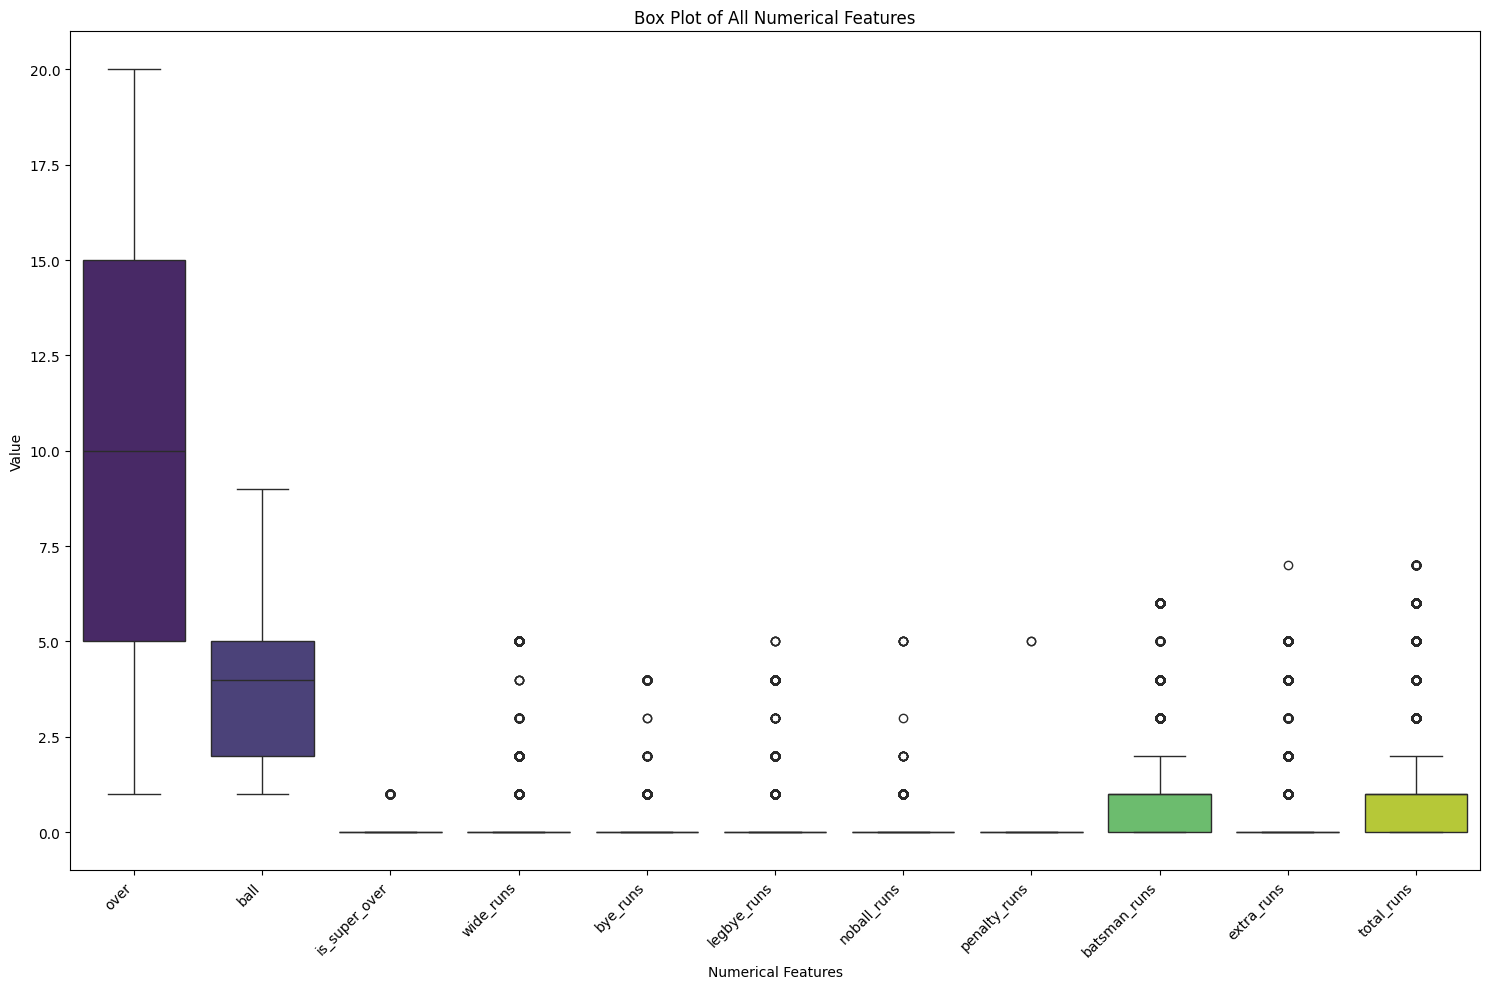

In [108]:
#Using dataset.melts fro visualising multiple numerical columns using box plot.
melted_data_before_capping = delivery_dataset.melt(
                    value_vars= numerical_columns,var_name='Numerical Feature',
                    value_name='Value')

#Create a sigle figure with subplots for each box plot.
plt.figure(figsize=(15,10))
sea.boxplot(x='Numerical Feature',y='Value', hue='Numerical Feature',
            data=melted_data_before_capping,palette='viridis', legend=False)
plt.title("Box Plot of All Numerical Features")
plt.xlabel('Numerical Features')
plt.ylabel("Value")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

"i" decided to keep the dataset with outliers because you found that the capping process "ruined the data." In the context of cricket, what might appear as a statistical outlier can often be a meaningful and crucial data point, and you preferred to retain the original distribution and its contextual significance.

In [109]:
# player_dismissed	143022
# dismissal_kind	143022
# fielder	145091

delivery_dataset['player_dismissed']= delivery_dataset['player_dismissed'].fillna("not out")

delivery_dataset['dismissal_kind'] = delivery_dataset['dismissal_kind'].fillna("N/A")

delivery_dataset['fielder'] = delivery_dataset['fielder'].fillna("N/A")


In [110]:
delivery_dataset.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batsman,0
non_striker,0
bowler,0
is_super_over,0


In [111]:
print(f"Number of duplicate rows: {delivery_dataset.duplicated().sum()}")

Number of duplicate rows: 1


In [112]:
delivery_dataset.drop_duplicates(inplace=True)

In [113]:
print(f"Number of duplicate rows after dropping: {delivery_dataset.duplicated().sum()}")

Number of duplicate rows after dropping: 0


In [114]:
print("Dataset after cleaning:")
display(delivery_dataset.head())

Dataset after cleaning:


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,not out,N/A,N/A
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,not out,N/A,N/A
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,not out,N/A,N/A
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,not out,N/A,N/A
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,not out,N/A,N/A


As my datset is cleaned now i will start plotting graphs..

In [115]:
display(f"The dataset has these columns: {dataset.columns}")

"The dataset has these columns: Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',\n       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',\n       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',\n       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',\n       'dismissal_kind', 'fielder'],\n      dtype='object')"

In [116]:
all_teams = np.unique(delivery_dataset[['batting_team']])
print("Teams Before Standardising names: ",len(all_teams))
display(all_teams)

Teams Before Standardising names:  14


array(['Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredevils',
       'Gujarat Lions', 'Kings XI Punjab', 'Kochi Tuskers Kerala',
       'Kolkata Knight Riders', 'Mumbai Indians', 'Pune Warriors',
       'Rajasthan Royals', 'Rising Pune Supergiant',
       'Rising Pune Supergiants', 'Royal Challengers Bangalore',
       'Sunrisers Hyderabad'], dtype=object)

In [117]:
same_team_name = {
                  'Rising Pune Supergiants' : 'Rising Pune Supergiant',
                  'Delhi Daredevils':'Delhi Capitals',
                  'Deccan Chargers':'Sunrisers Hyderabad',
                  'Kings XI Punjab':"Punjab Kings"
}

def standardised_team_name(df,columns):
  for col in columns:
    df[col] = df[col].replace(same_team_name)
  return df

team_columns= ['batting_team', 'bowling_team']
delivery_dataset = standardised_team_name(delivery_dataset,team_columns)

In [118]:
all_teams = np.unique(delivery_dataset[['batting_team']])
print("Teams After Standardising names: ",len(all_teams))
display(all_teams)

Teams After Standardising names:  12


array(['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions',
       'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Mumbai Indians',
       'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Sunrisers Hyderabad'], dtype=object)

In [119]:
dataset['match_id'].nunique()

636

Top 10 Batsmen who faced the most balls:


,count
batsman,
V Kohli,3494
G Gambhir,3433
SK Raina,3369
RG Sharma,3274
S Dhawan,3005
RV Uthappa,2960
DA Warner,2902
MS Dhoni,2680
AM Rahane,2602


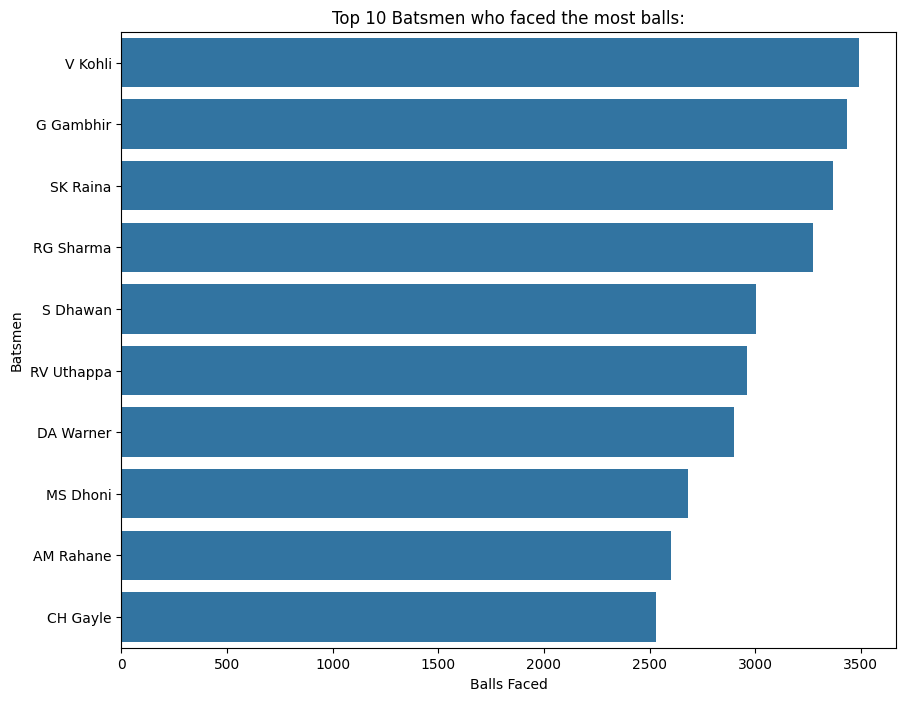

Top 10 Bowler who bowled most balls: 


,count
bowler,
Harbhajan Singh,2989
A Mishra,2703
SL Malinga,2694
P Kumar,2637
PP Chawla,2594
R Ashwin,2359
Z Khan,2276
R Vinay Kumar,2161
DW Steyn,2159


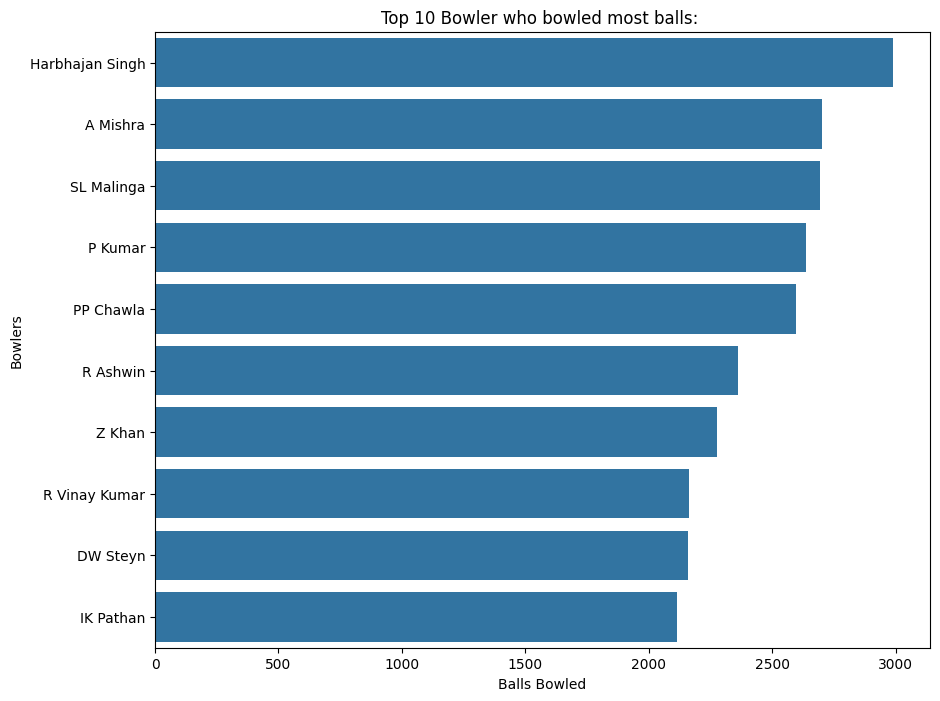

In [120]:
print("Top 10 Batsmen who faced the most balls:")
top_10_most_ball_faced_batsman = delivery_dataset['batsman'].value_counts().head(10)
display(delivery_dataset['batsman'].value_counts().head(10))
plt.figure(figsize=(10,8))
sea.barplot(x=top_10_most_ball_faced_batsman.values,
           y=top_10_most_ball_faced_batsman.index,)
plt.title("Top 10 Batsmen who faced the most balls:")
plt.xlabel("Balls Faced")
plt.ylabel("Batsmen")
plt.show()

print("Top 10 Bowler who bowled most balls: ")
top_10_most_bowled_baller = delivery_dataset['bowler'].value_counts().head(10)
display(top_10_most_bowled_baller)
plt.figure(figsize=(10,8))
sea.barplot(x=top_10_most_bowled_baller.values,
           y=top_10_most_bowled_baller.index,)
plt.title("Top 10 Bowler who bowled most balls: ")
plt.xlabel("Balls Bowled")
plt.ylabel("Bowlers")

plt.show()

In [121]:
top_scoring_batsmen = delivery_dataset.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False)
display(top_scoring_batsmen.head(10))

top_10_most_dismissed_players = delivery_dataset['player_dismissed'].value_counts().head(11)
display(top_10_most_dismissed_players)

,batsman_runs
batsman,
SK Raina,4548
V Kohli,4423
RG Sharma,4207
G Gambhir,4132
DA Warner,4014
RV Uthappa,3778
CH Gayle,3651
S Dhawan,3561
MS Dhoni,3560


,count
player_dismissed,
not out,143021
SK Raina,134
G Gambhir,131
RG Sharma,129
RV Uthappa,128
V Kohli,118
KD Karthik,117
S Dhawan,109
PA Patel,107


In [122]:
#bowler_who_gave_most_runs
most_run_giving_bowler = delivery_dataset.groupby('bowler')['total_runs'].sum().sort_values(ascending=False)
display(most_run_giving_bowler)

,total_runs
bowler,
Harbhajan Singh,3453
P Kumar,3342
PP Chawla,3315
A Mishra,3305
SL Malinga,3034
...,...
LA Carseldine,6
AM Rahane,5
SPD Smith,5


In [123]:
bowler_who_bowled_most_wide = delivery_dataset.groupby('bowler')['wide_runs'].sum().sort_values(ascending=False)
# display(bowler_who_bowled_most_wide)

bowler_who_bowled_most_no_balls = delivery_dataset.groupby('bowler')['noball_runs'].sum().sort_values(ascending=False).head(10)
# display(bowler_who_bowled_most_no_balls)

bowlers_who_bowled_most_bye_runs = delivery_dataset.groupby('bowler')['bye_runs'].sum().sort_values(ascending=False).head(10)
# display(bowlers_who_bowled_most_bye_runs)

bowlers_who_bowled_most_legbye_runs = delivery_dataset.groupby('bowler')['legbye_runs'].sum().sort_values(ascending=False).head(10)
# display(bowlers_who_bowled_most_legbye_runs)

bowler_who_bowled_most_penalty_runs = delivery_dataset.groupby('bowler')['penalty_runs'].sum().sort_values(ascending=False).head(10)
# display(bowler_who_bowled_most_penalty_runs)

bowler_who_bowled_extra_runs_overall = delivery_dataset.groupby('bowler')['extra_runs'].sum().sort_values(ascending=False).head(10)
display(bowler_who_bowled_extra_runs_overall)

,extra_runs
bowler,
SL Malinga,268
P Kumar,236
UT Yadav,186
RP Singh,181
Z Khan,169
I Sharma,167
DW Steyn,166
B Kumar,166
SR Watson,162


In [124]:
all_matchups = dataset[['batting_team','bowling_team']].value_counts().reset_index()
# all_matchups.value_counts()
all_matchups

,batting_team,bowling_team,count
0,Chennai Super Kings,Mumbai Indians,2685
1,Mumbai Indians,Chennai Super Kings,2662
2,Kings XI Punjab,Kolkata Knight Riders,2590
3,Royal Challengers Bangalore,Mumbai Indians,2574
4,Mumbai Indians,Royal Challengers Bangalore,2556
...,...,...,...
141,Kochi Tuskers Kerala,Pune Warriors,123
142,Pune Warriors,Kochi Tuskers Kerala,123
143,Kochi Tuskers Kerala,Mumbai Indians,121
144,Kings XI Punjab,Kochi Tuskers Kerala,118


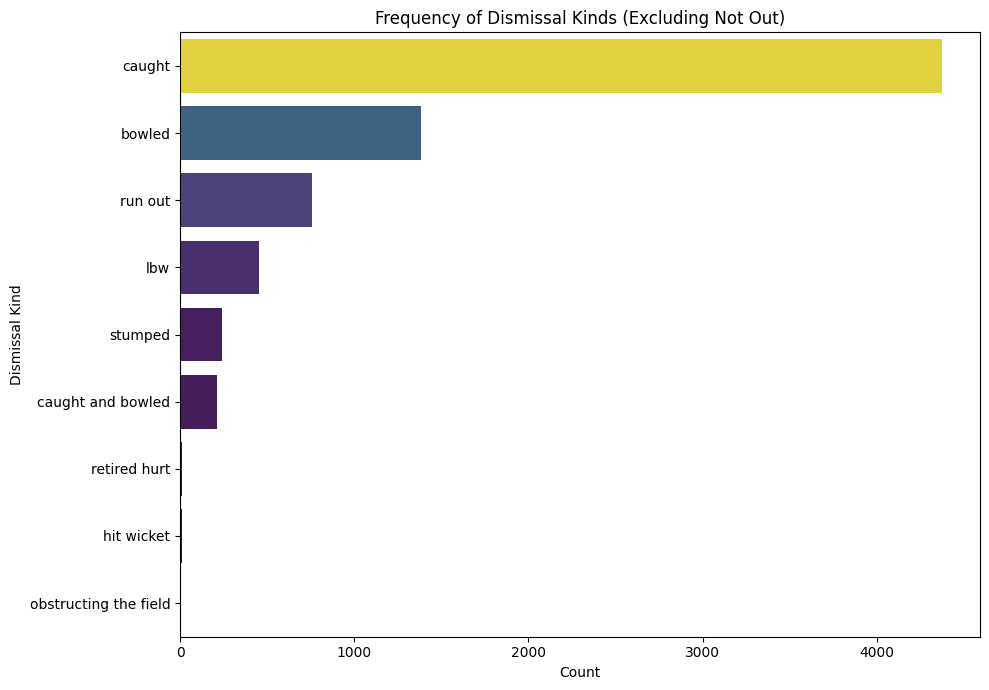

In [125]:
dismissal_kinds_fequency = delivery_dataset['dismissal_kind'].value_counts().sort_values(ascending=False)

# Filter out 'N/A' to focus on actual dismissal kinds for visualization
dismissal_kinds_for_plot = dismissal_kinds_fequency[dismissal_kinds_fequency.index != 'N/A']

plt.figure(figsize=(10, 7))
sea.barplot(x=dismissal_kinds_for_plot.values, y=dismissal_kinds_for_plot.index, palette='viridis',hue=dismissal_kinds_for_plot.values,legend=False)
plt.title('Frequency of Dismissal Kinds (Excluding Not Out)')
plt.xlabel('Count')
plt.ylabel('Dismissal Kind')
plt.tight_layout()
plt.show()

In [126]:
fielder_who_caught_most_balls = delivery_dataset['fielder'].value_counts().head(10)
fielder_who_caught_most_balls_plot =fielder_who_caught_most_balls[fielder_who_caught_most_balls.index!='N/A']
display(fielder_who_caught_most_balls_plot)

,count
fielder,
KD Karthik,127
MS Dhoni,126
RV Uthappa,115
AB de Villiers,101
SK Raina,96
PA Patel,84
NV Ojha,82
RG Sharma,79
AC Gilchrist,75


In [127]:
teams_and_extra_runs = delivery_dataset.groupby('bowling_team')['extra_runs'].sum().sort_values(ascending=False).head(12)
display(teams_and_extra_runs)

,extra_runs
bowling_team,
Mumbai Indians,1397
Royal Challengers Bangalore,1309
Punjab Kings,1230
Kolkata Knight Riders,1204
Delhi Capitals,1187
Sunrisers Hyderabad,1146
Rajasthan Royals,1058
Chennai Super Kings,1002
Pune Warriors,335


In [128]:
# Filter for dismissal kinds where the bowler is credited
bowler_credited_dismissals = delivery_dataset[
    delivery_dataset['dismissal_kind'].isin(['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled'])
]

# Group by bowler and count the dismissals, then sort
wickets_by_bowler = bowler_credited_dismissals.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False)
wickets_by_bowler= wickets_by_bowler.reset_index()
wickets_by_bowler.rename(columns={'dismissal_kind':'no.of_wickets'},inplace=True)
display(wickets_by_bowler.head(10)) # Displaying top 10 wicket-takers

,bowler,no.of_wickets
0,SL Malinga,154
1,A Mishra,134
2,Harbhajan Singh,126
3,PP Chawla,126
4,DJ Bravo,122
5,B Kumar,111
6,A Nehra,106
7,R Vinay Kumar,103
8,Z Khan,102
9,R Ashwin,100


In [129]:
#Run conceded by each bowler
bowler_total_runs = delivery_dataset.groupby('bowler')['total_runs'].sum().reset_index()

bowler_total_runs.rename(columns={'total_runs':'runs_conceded'},inplace=True)

#Merge with wickets_by_bowler dataframe
bowler_stats = pd.merge(bowler_total_runs,wickets_by_bowler,on='bowler',how='left')
bowler_stats['no.of_wickets'] = bowler_stats['no.of_wickets'].fillna(0)

# Vectorized bowling average calculation
# Handle division by zero by replacing 0 with NaN, then filling NaN with inf after division
bowler_stats['bowling_average'] = bowler_stats['runs_conceded'] / bowler_stats['no.of_wickets'].replace(0, np.nan)
bowler_stats['bowling_average'] = bowler_stats['bowling_average'].fillna(np.inf)

display(bowler_stats.sort_values(by=['bowling_average']).head(30))

,bowler,runs_conceded,no.of_wickets,bowling_average
20,AC Gilchrist,0,1.0,0.000000
310,Sachin Baby,8,2.0,4.000000
32,AM Rahane,5,1.0,5.000000
305,SS Mundhe,6,1.0,6.000000
170,LA Carseldine,6,1.0,6.000000
85,DAJ Bracewell,32,3.0,10.666667
316,Shoaib Akhtar,54,5.0,10.800000
29,AJ Tye,146,12.0,12.166667
318,Sohail Tanvir,275,22.0,12.500000
93,DJ Thornely,40,3.0,13.333333


In [130]:
display(bowler_stats.sort_values(by='no.of_wickets', ascending=False).head(10))

,bowler,runs_conceded,no.of_wickets,bowling_average
294,SL Malinga,3034,154.0,19.701299
5,A Mishra,3305,134.0,24.664179
117,Harbhajan Singh,3453,126.0,27.404762
229,PP Chawla,3315,126.0,26.309524
88,DJ Bravo,2815,122.0,23.073770
50,B Kumar,2410,111.0,21.711712
7,A Nehra,2537,106.0,23.933962
244,R Vinay Kumar,2976,103.0,28.893204
355,Z Khan,2860,102.0,28.039216
234,R Ashwin,2552,100.0,25.520000


In [131]:
# delivery_dataset.groupby('bowler')['over'].nunique()

total_balls_bowled = delivery_dataset['bowler'].value_counts().reset_index()
total_balls_bowled.rename(columns={'count':"no_of_balls_bowled"},inplace=True)

total_overs = delivery_dataset.groupby('bowler')['over'].nunique().reset_index()
total_overs.rename(columns={'over':'no_of_overs'},inplace=True)

bowler_stats = pd.merge(bowler_stats, total_balls_bowled, on='bowler',how='left')
bowler_stats = pd.merge(bowler_stats, total_overs,on='bowler',how='left')

# bowler_stats.head()



In [132]:
total_dot_balls = delivery_dataset[delivery_dataset['total_runs'] == 0].groupby('bowler')['total_runs'].value_counts().reset_index()

total_dot_balls.rename(columns={'count':'total_dot_balls'},inplace=True)
total_dot_balls

bowler_stats = pd.merge(bowler_stats, total_dot_balls,on='bowler', how='left')
bowler_stats.drop(columns=['total_runs'],axis=1)

,bowler,runs_conceded,no.of_wickets,bowling_average,no_of_balls_bowled,no_of_overs,total_dot_balls
0,A Ashish Reddy,400,18.0,22.222222,270,15,79.0
1,A Chandila,245,11.0,22.272727,234,9,103.0
2,A Choudhary,144,5.0,28.800000,108,12,42.0
3,A Flintoff,106,2.0,53.000000,66,10,20.0
4,A Kumble,1089,45.0,24.200000,983,20,374.0
...,...,...,...,...,...,...,...
351,YA Abdulla,311,15.0,20.733333,222,17,88.0
352,YK Pathan,1421,41.0,34.658537,1166,19,390.0
353,YS Chahal,1600,70.0,22.857143,1219,20,405.0
354,Yuvraj Singh,1068,36.0,29.666667,869,13,258.0


In [133]:
# Filter for dismissal kinds where the bowler is credited
bowler_credited_deliveries_per_match = delivery_dataset[
    delivery_dataset['dismissal_kind'].isin(['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled'])
]

bowler_wickets_per_match = bowler_credited_deliveries_per_match.groupby(['match_id', 'bowler'])['dismissal_kind'].count().reset_index()
bowler_wickets_per_match.rename(columns={'dismissal_kind':'wickets_in_match'},inplace=True)

display(bowler_wickets_per_match.head())

,match_id,bowler,wickets_in_match
0,1,A Choudhary,1
1,1,A Nehra,2
2,1,B Kumar,2
3,1,Bipul Sharma,1
4,1,DJ Hooda,1


In [134]:
# Calculate 4-wicket hauls (count of matches where bowler took >= 4 wickets)
four_wicket_hauls_count = bowler_wickets_per_match[bowler_wickets_per_match['wickets_in_match'] >= 4].groupby('bowler')['match_id'].count().reset_index(name='four_plus_wickets_total')

# Calculate 5-wicket hauls (count of matches where bowler took >= 5 wickets)
five_wicket_hauls_count = bowler_wickets_per_match[bowler_wickets_per_match['wickets_in_match'] >= 5].groupby('bowler')['match_id'].count().reset_index(name='five_plus_wickets_total')

# Merge these counts into bowler_stats
bowler_stats = pd.merge(bowler_stats, four_wicket_hauls_count, on='bowler', how='left')
bowler_stats = pd.merge(bowler_stats, five_wicket_hauls_count, on='bowler', how='left')

# Fill NaN values with 0 for bowlers who don't have any 4+ or 5+ wicket hauls
bowler_stats['four_plus_wickets_total'] = bowler_stats['four_plus_wickets_total'].fillna(0).astype(int)
bowler_stats['five_plus_wickets_total'] = bowler_stats['five_plus_wickets_total'].fillna(0).astype(int)

display(bowler_stats.sort_values(by=['five_plus_wickets_total', 'four_plus_wickets_total'], ascending=False).head(10))

,bowler,runs_conceded,no.of_wickets,bowling_average,no_of_balls_bowled,no_of_overs,total_runs,total_dot_balls,four_plus_wickets_total,five_plus_wickets_total
144,JP Faulkner,1849,61.0,30.311475,1287,20,0.0,399.0,3,2
133,JD Unadkat,1328,56.0,23.714286,995,20,0.0,354.0,2,2
300,SP Narine,2085,95.0,21.947368,1956,20,0.0,817.0,7,1
294,SL Malinga,3034,154.0,19.701299,2694,20,0.0,1060.0,5,1
5,A Mishra,3305,134.0,24.664179,2703,20,0.0,953.0,4,1
169,L Balaji,2083,76.0,27.407895,1574,20,0.0,537.0,4,1
245,RA Jadeja,2540,82.0,30.975610,1962,20,0.0,612.0,4,1
4,A Kumble,1089,45.0,24.200000,983,20,0.0,374.0,3,1
50,B Kumar,2410,111.0,21.711712,2054,20,0.0,832.0,3,1
196,MM Patel,1733,74.0,23.418919,1382,20,0.0,590.0,3,1


In [135]:
total_matches_played_by_bowler = delivery_dataset.groupby('bowler')['match_id'].nunique()

total_matches_played_by_bowler

bowler_stats = pd.merge(bowler_stats, total_matches_played_by_bowler, on = 'bowler', how='left')
bowler_stats.rename(columns={'match_id':'matches_played'},inplace=True)

In [136]:
bowler_stats['bowling_economy'] = bowler_stats['runs_conceded']/bowler_stats['no_of_overs'].replace(0,np.nan)
bowler_stats['bowling_economy'] = bowler_stats['bowling_economy'].fillna(np.inf)

bowler_stats['average_dot_balls'] = ((bowler_stats['total_dot_balls']/bowler_stats['no_of_balls_bowled'])*100).replace(0,np.nan)
bowler_stats['average_dot_balls'] = bowler_stats['average_dot_balls'].fillna(np.inf)

# display(bowler_stats[bowler_stats['average_dot_balls'] != np.inf].sort_values(by='average_dot_balls', ascending=False))

display(bowler_stats[(bowler_stats['average_dot_balls'] != np.inf) & (bowler_stats['matches_played']>=50)].sort_values(by='average_dot_balls', ascending=False))

bowler_stats.drop(columns=['total_runs'])

,bowler,runs_conceded,no.of_wickets,bowling_average,no_of_balls_bowled,no_of_overs,total_runs,total_dot_balls,four_plus_wickets_total,five_plus_wickets_total,matches_played,bowling_economy,average_dot_balls
103,DW Steyn,2375,91.0,26.098901,2159,19,0.0,978.0,0,0,90,125.000000,45.298749
196,MM Patel,1733,74.0,23.418919,1382,20,0.0,590.0,3,1,63,86.650000,42.691751
311,Sandeep Sharma,1623,71.0,22.859155,1273,20,0.0,534.0,2,0,56,81.150000,41.948154
300,SP Narine,2085,95.0,21.947368,1956,20,0.0,817.0,7,1,81,104.250000,41.768916
180,M Morkel,2136,77.0,27.740260,1699,19,0.0,708.0,1,0,70,112.421053,41.671572
121,I Sharma,2291,58.0,39.500000,1713,20,0.0,700.0,1,1,76,114.550000,40.863981
218,P Kumar,3342,90.0,37.133333,2637,20,0.0,1075.0,0,0,119,167.100000,40.766022
50,B Kumar,2410,111.0,21.711712,2054,20,0.0,832.0,3,1,90,120.500000,40.506329
7,A Nehra,2537,106.0,23.933962,1974,20,0.0,798.0,1,0,88,126.850000,40.425532
101,DS Kulkarni,1918,76.0,25.236842,1485,20,0.0,600.0,1,0,72,95.900000,40.404040


,bowler,runs_conceded,no.of_wickets,bowling_average,no_of_balls_bowled,no_of_overs,total_dot_balls,four_plus_wickets_total,five_plus_wickets_total,matches_played,bowling_economy,average_dot_balls
0,A Ashish Reddy,400,18.0,22.222222,270,15,79.0,0,0,20,26.666667,29.259259
1,A Chandila,245,11.0,22.272727,234,9,103.0,1,0,12,27.222222,44.017094
2,A Choudhary,144,5.0,28.800000,108,12,42.0,0,0,5,12.000000,38.888889
3,A Flintoff,106,2.0,53.000000,66,10,20.0,0,0,3,10.600000,30.303030
4,A Kumble,1089,45.0,24.200000,983,20,374.0,3,1,42,54.450000,38.046796
...,...,...,...,...,...,...,...,...,...,...,...,...
351,YA Abdulla,311,15.0,20.733333,222,17,88.0,2,0,11,18.294118,39.639640
352,YK Pathan,1421,41.0,34.658537,1166,19,390.0,0,0,80,74.789474,33.447684
353,YS Chahal,1600,70.0,22.857143,1219,20,405.0,1,0,55,80.000000,33.223954
354,Yuvraj Singh,1068,36.0,29.666667,869,13,258.0,2,0,71,82.153846,29.689298


In [137]:
bowler_stats['bowling_strike_rate'] = bowler_stats['no_of_balls_bowled'] / bowler_stats['no.of_wickets'].replace(0,np.nan)

bowler_stats['bowling_strike_rate'] = bowler_stats['bowling_strike_rate'].fillna(np.inf)

bowler_stats

,bowler,runs_conceded,no.of_wickets,bowling_average,no_of_balls_bowled,no_of_overs,total_runs,total_dot_balls,four_plus_wickets_total,five_plus_wickets_total,matches_played,bowling_economy,average_dot_balls,bowling_strike_rate
0,A Ashish Reddy,400,18.0,22.222222,270,15,0.0,79.0,0,0,20,26.666667,29.259259,15.000000
1,A Chandila,245,11.0,22.272727,234,9,0.0,103.0,1,0,12,27.222222,44.017094,21.272727
2,A Choudhary,144,5.0,28.800000,108,12,0.0,42.0,0,0,5,12.000000,38.888889,21.600000
3,A Flintoff,106,2.0,53.000000,66,10,0.0,20.0,0,0,3,10.600000,30.303030,33.000000
4,A Kumble,1089,45.0,24.200000,983,20,0.0,374.0,3,1,42,54.450000,38.046796,21.844444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,YA Abdulla,311,15.0,20.733333,222,17,0.0,88.0,2,0,11,18.294118,39.639640,14.800000
352,YK Pathan,1421,41.0,34.658537,1166,19,0.0,390.0,0,0,80,74.789474,33.447684,28.439024
353,YS Chahal,1600,70.0,22.857143,1219,20,0.0,405.0,1,0,55,80.000000,33.223954,17.414286
354,Yuvraj Singh,1068,36.0,29.666667,869,13,0.0,258.0,2,0,71,82.153846,29.689298,24.138889


In [138]:
bowler_stats.columns

Index(['bowler', 'runs_conceded', 'no.of_wickets', 'bowling_average',
       'no_of_balls_bowled', 'no_of_overs', 'total_runs', 'total_dot_balls',
       'four_plus_wickets_total', 'five_plus_wickets_total', 'matches_played',
       'bowling_economy', 'average_dot_balls', 'bowling_strike_rate'],
      dtype='object')

In [139]:
bowler_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   bowler                   356 non-null    object 
 1   runs_conceded            356 non-null    int64  
 2   no.of_wickets            356 non-null    float64
 3   bowling_average          356 non-null    float64
 4   no_of_balls_bowled       356 non-null    int64  
 5   no_of_overs              356 non-null    int64  
 6   total_runs               347 non-null    float64
 7   total_dot_balls          347 non-null    float64
 8   four_plus_wickets_total  356 non-null    int64  
 9   five_plus_wickets_total  356 non-null    int64  
 10  matches_played           356 non-null    int64  
 11  bowling_economy          356 non-null    float64
 12  average_dot_balls        356 non-null    float64
 13  bowling_strike_rate      356 non-null    float64
dtypes: float64(7), int64(6), o

In [140]:
# batsmen_total_runs = top_scoring_batsmen.copy()
# batsman_total_balls = delivery_dataset['batsman'].value_counts().reset_index()

# batsman_total_balls.rename(columns={'count':'no.of_balls'},inplace=True)
# display(batsmen_total_runs)

# batsmen_stats = pd.merge(batsmen_total_runs,batsman_total_balls,on='batsman',how='left')

# display(batsmen_stats,batsmen_stats.isnull().sum())
# batsmen_stats['strike_rate']= batsmen_stats.apply(lambda row: (row['batsman_runs']/row['no.of_balls'])*100 if row['no.of_balls'] > 0 else np.inf, axis=1)


In [141]:
batsmen_total_runs = top_scoring_batsmen.copy()
batsman_total_balls = delivery_dataset['batsman'].value_counts().reset_index()

batsman_total_balls.rename(columns={'count':'no.of_balls'},inplace=True)
display(batsmen_total_runs)

batsmen_stats = pd.merge(batsmen_total_runs,batsman_total_balls,on='batsman',how='left')

display(batsmen_stats,batsmen_stats.isnull().sum())

# Vectorized strike rate calculation
# Handle division by zero by replacing 0 with NaN, then filling NaN with inf after division
batsmen_stats['strike_rate'] = (batsmen_stats['batsman_runs'] / batsmen_stats['no.of_balls'].replace(0, np.nan)) * 100
batsmen_stats['strike_rate'] = batsmen_stats['strike_rate'].fillna(np.inf)

display(batsmen_stats)

,batsman_runs
batsman,
SK Raina,4548
V Kohli,4423
RG Sharma,4207
G Gambhir,4132
DA Warner,4014
...,...
RR Bhatkal,0
M Ashwin,0
Abdur Razzak,0


,batsman,batsman_runs,no.of_balls
0,SK Raina,4548,3369
1,V Kohli,4423,3494
2,RG Sharma,4207,3274
3,G Gambhir,4132,3433
4,DA Warner,4014,2902
...,...,...,...
456,RR Bhatkal,0,2
457,M Ashwin,0,1
458,Abdur Razzak,0,2
459,IC Pandey,0,2


,0
batsman,0
batsman_runs,0
no.of_balls,0


,batsman,batsman_runs,no.of_balls,strike_rate
0,SK Raina,4548,3369,134.995548
1,V Kohli,4423,3494,126.588437
2,RG Sharma,4207,3274,128.497251
3,G Gambhir,4132,3433,120.361200
4,DA Warner,4014,2902,138.318401
...,...,...,...,...
456,RR Bhatkal,0,2,0.000000
457,M Ashwin,0,1,0.000000
458,Abdur Razzak,0,2,0.000000
459,IC Pandey,0,2,0.000000


In [142]:
total_dismissals_df = delivery_dataset['player_dismissed'].value_counts().reset_index()
total_dismissals_df.columns = ['batsman','dismissals_count']
total_dismissals_df = total_dismissals_df[total_dismissals_df['batsman'] != 'not out']

batsmen_stats = pd.merge(batsmen_stats, total_dismissals_df, on='batsman',how='left')
batsmen_stats['dismissals_count'] = batsmen_stats['dismissals_count'].fillna(0)
batsmen_stats['batting_average'] = batsmen_stats['batsman_runs'] / batsmen_stats['dismissals_count'].replace(0,np.nan)
batsmen_stats['batting_average'] = batsmen_stats['batting_average'].fillna(np.inf)

display(batsmen_stats.sort_values(by='batting_average', ascending=False).head(10))
display(batsmen_stats.sort_values(by='batsman_runs',ascending=False).head(10))

,batsman,batsman_runs,no.of_balls,strike_rate,dismissals_count,batting_average
458,Abdur Razzak,0,2,0.000000,0.0,inf
442,PM Sarvesh Kumar,1,2,50.000000,0.0,inf
436,RG More,2,2,100.000000,0.0,inf
438,P Parameswaran,1,3,33.333333,0.0,inf
440,DP Vijaykumar,1,1,100.000000,0.0,inf
427,Mashrafe Mortaza,2,2,100.000000,0.0,inf
410,CRD Fernando,4,3,133.333333,0.0,inf
407,A Chandila,4,7,57.142857,0.0,inf
402,TA Boult,5,8,62.500000,0.0,inf
401,KMDN Kulasekara,5,3,166.666667,0.0,inf


,batsman,batsman_runs,no.of_balls,strike_rate,dismissals_count,batting_average
0,SK Raina,4548,3369,134.995548,134.0,33.940299
1,V Kohli,4423,3494,126.588437,118.0,37.483051
2,RG Sharma,4207,3274,128.497251,129.0,32.612403
3,G Gambhir,4132,3433,120.361200,131.0,31.541985
4,DA Warner,4014,2902,138.318401,100.0,40.140000
5,RV Uthappa,3778,2960,127.635135,128.0,29.515625
6,CH Gayle,3651,2532,144.194313,89.0,41.022472
7,S Dhawan,3561,3005,118.502496,109.0,32.669725
8,MS Dhoni,3560,2680,132.835821,94.0,37.872340
9,AB de Villiers,3486,2402,145.129059,91.0,38.307692


In [143]:
batsman_fours = delivery_dataset[delivery_dataset['batsman_runs'] == 4].groupby('batsman')['batsman_runs'].count().reset_index()
batsman_fours.rename(columns={'batsman_runs': 'no_of_fours'}, inplace=True)

batsman_sixes = delivery_dataset[delivery_dataset['batsman_runs'] == 6].groupby('batsman')['batsman_runs'].count().reset_index()
batsman_sixes.rename(columns={'batsman_runs': 'no_of_sixes'}, inplace=True)

batsmen_stats = pd.merge(batsmen_stats, batsman_fours, on='batsman', how='left')
batsmen_stats = pd.merge(batsmen_stats, batsman_sixes, on='batsman', how='left')

batsmen_stats['no_of_fours'] = batsmen_stats['no_of_fours'].fillna(0).astype(int)
batsmen_stats['no_of_sixes'] = batsmen_stats['no_of_sixes'].fillna(0).astype(int)

display(batsmen_stats.head())

,batsman,batsman_runs,no.of_balls,strike_rate,dismissals_count,batting_average,no_of_fours,no_of_sixes
0,SK Raina,4548,3369,134.995548,134.0,33.940299,402,174
1,V Kohli,4423,3494,126.588437,118.0,37.483051,384,160
2,RG Sharma,4207,3274,128.497251,129.0,32.612403,354,173
3,G Gambhir,4132,3433,120.361200,131.0,31.541985,484,58
4,DA Warner,4014,2902,138.318401,100.0,40.140000,401,160


In [144]:
batsmen_stats['boundary_percentage'] = (((batsmen_stats['no_of_fours'] * 4) + (batsmen_stats['no_of_sixes'] * 6)) / batsmen_stats['batsman_runs'].replace(0, np.nan)) * 100

batsmen_stats['boundary_percentage']= batsmen_stats['boundary_percentage'].fillna(0)

display(batsmen_stats)

,batsman,batsman_runs,no.of_balls,strike_rate,dismissals_count,batting_average,no_of_fours,no_of_sixes,boundary_percentage
0,SK Raina,4548,3369,134.995548,134.0,33.940299,402,174,58.311346
1,V Kohli,4423,3494,126.588437,118.0,37.483051,384,160,56.432286
2,RG Sharma,4207,3274,128.497251,129.0,32.612403,354,173,58.331353
3,G Gambhir,4132,3433,120.361200,131.0,31.541985,484,58,55.275895
4,DA Warner,4014,2902,138.318401,100.0,40.140000,401,160,63.876432
...,...,...,...,...,...,...,...,...,...
456,RR Bhatkal,0,2,0.000000,1.0,0.000000,0,0,0.000000
457,M Ashwin,0,1,0.000000,1.0,0.000000,0,0,0.000000
458,Abdur Razzak,0,2,0.000000,0.0,inf,0,0,0.000000
459,IC Pandey,0,2,0.000000,1.0,0.000000,0,0,0.000000


In [145]:
batsman_runs_per_match = delivery_dataset.groupby(['match_id','batsman'])['batsman_runs'].sum().reset_index()

def count_hundreds(runs):
  return (runs >= 100).sum()


def count_fifties(runs):
  return ((runs >=50) & (runs<100)).sum()

hundreds = batsman_runs_per_match.groupby('batsman')['batsman_runs'].apply(count_hundreds).reset_index(name='no_of_100s')

fifties = batsman_runs_per_match.groupby('batsman')['batsman_runs'].apply(count_fifties).reset_index(name='no_of_50s')

batsmen_stats = pd.merge(batsmen_stats, hundreds,on='batsman',how='left')
batsmen_stats = pd.merge(batsmen_stats, fifties, on='batsman',how='left')

batsmen_stats['no_of_100s'] = batsmen_stats['no_of_100s'].fillna(0).astype(int)
batsmen_stats['no_of_50s'] = batsmen_stats['no_of_50s'].fillna(0).astype(int)

In [146]:
batsmen_stats

,batsman,batsman_runs,no.of_balls,strike_rate,dismissals_count,batting_average,no_of_fours,no_of_sixes,boundary_percentage,no_of_100s,no_of_50s
0,SK Raina,4548,3369,134.995548,134.0,33.940299,402,174,58.311346,1,31
1,V Kohli,4423,3494,126.588437,118.0,37.483051,384,160,56.432286,4,31
2,RG Sharma,4207,3274,128.497251,129.0,32.612403,354,173,58.331353,1,32
3,G Gambhir,4132,3433,120.361200,131.0,31.541985,484,58,55.275895,0,35
4,DA Warner,4014,2902,138.318401,100.0,40.140000,401,160,63.876432,3,36
...,...,...,...,...,...,...,...,...,...,...,...
456,RR Bhatkal,0,2,0.000000,1.0,0.000000,0,0,0.000000,0,0
457,M Ashwin,0,1,0.000000,1.0,0.000000,0,0,0.000000,0,0
458,Abdur Razzak,0,2,0.000000,0.0,inf,0,0,0.000000,0,0
459,IC Pandey,0,2,0.000000,1.0,0.000000,0,0,0.000000,0,0


In [147]:
delivery_dataset.groupby('bowler')['over'].nunique()

,over
bowler,
A Ashish Reddy,15
A Chandila,9
A Choudhary,12
A Flintoff,10
A Kumble,20
...,...
YA Abdulla,17
YK Pathan,19
YS Chahal,20


In [148]:
dataset.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


## Comprehensive EDA Review and Next Steps

That's an excellent set of questions! It shows you're thinking critically about your analysis, which is a hallmark of a good data analyst.

### Your EDA Approach (ignoring structure for now):

**Strengths:**

1.  **Thorough Cleaning:** You've done a great job handling missing values, dropping duplicates, and standardizing team names. This foundational work is crucial for reliable analysis.
2.  **Comprehensive Player Statistics:** You've calculated a rich set of metrics for both bowlers and batsmen (average, strike rate, economy, dot balls, dismissals, boundaries, 50s/100s, 4/5 wicket hauls). These are highly relevant and insightful for cricket analysis.
3.  **Domain Knowledge Application:** Your understanding of what constitutes a 'dismissal' for a bowler (excluding 'not out' for batsmen) and handling division by zero for averages/strike rates demonstrates a good grasp of both data manipulation and the sport's nuances.
4.  **Calculations are Spot On:** The way you've derived metrics like `bowling_strike_rate` and `batting_average` is correct, and using `np.inf` for cases with zero wickets/dismissals is a robust way to handle them.

**Areas for Consideration/Improvement:**

1.  **Early Visualizations:** While you plan to plot later, incorporating visualizations *as you discover* patterns can sometimes reveal insights you might miss by just looking at raw numbers. For example, a simple histogram of `bowling_strike_rate` or `batting_average` could quickly show the distribution and highlight outliers that need further investigation.
2.  **Context for Infinity (`np.inf`):** Be mindful when using `np.inf` in later analyses or visualizations. While mathematically correct, it can skew aggregates or plot scales. Sometimes, it might be better to filter out players with `inf` values for certain metrics if their sample size is too small (e.g., a bowler who bowled only a few balls and took no wickets).
3.  **Efficiency in Dropping Columns:** In cell `aT0qiJknfeKf`, you have `bowler_stats.drop(columns=['total_runs'])`. For this to permanently modify the DataFrame, you'll need to either reassign it (`bowler_stats = bowler_stats.drop(...)`) or use `inplace=True` (`bowler_stats.drop(..., inplace=True)`). Otherwise, the change won't persist.

### Merging `deliveries.csv` and `matches.csv`:

**Absolutely, YES!** Merging `deliveries.csv` with `matches.csv` is a **critical next step** and will significantly enhance your analysis.

`deliveries.csv` gives you the granular, ball-by-ball details, but `matches.csv` provides the **context** for each match, such as:

*   **Match Result:** Who won, who lost, by how much.
*   **Toss Information:** Who won the toss, what they decided to do (bat/bowl).
*   **Venue:** Where the match was played.
*   **Date/Season:** When the match occurred.
*   **Player of the Match:** Who was the standout performer.

By merging them (likely on `match_id`), you can answer much more profound questions, such as:

*   Do teams winning the toss and choosing to bat/bowl have a significant advantage at certain venues?
*   How do individual player performances correlate with winning or losing matches?
*   Are there specific teams that perform exceptionally well at certain stadiums?
*   How have team strategies or player performances evolved across different IPL seasons?

### Saving `batsmen_stats` and `bowler_stats`:

**Yes, you should definitely save them!** These DataFrames (`batsmen_stats` and `bowler_stats`) are valuable outputs of your feature engineering and aggregation. Saving them allows you to:

1.  **Avoid Recalculation:** If your kernel crashes or you need to restart, you don't have to run all the previous cells to regenerate these statistics.
2.  **Further Analysis:** You can load these processed datasets directly into other notebooks or scripts for deeper analysis, visualization, or even machine learning tasks.
3.  **Reporting:** They serve as cleaned, aggregated data ready for reporting or dashboard creation.

You can save them to CSV files using `df.to_csv('filename.csv', index=False)`.

### My Honest Thoughts & Rating:

For a beginner, your EDA is **very impressive**! You've gone beyond basic data cleaning and delved deep into domain-specific feature engineering, which is a fantastic sign. You're asking the right questions about how to proceed, which shows a strong analytical mindset. I'd rate your current approach as **"Excellent for a beginner, with a clear path to becoming proficient."** Keep up the great work!

In [149]:
#saving cleaned datasets:

bowler_stats.to_csv('bowler_stats.csv')

batsmen_stats.to_csv('batsmen_stats.csv')

In [150]:
from google.colab import files

files.download('bowler_stats.csv')
files.download('batsmen_stats.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [151]:
dataset = pd.read_csv('/kaggle/input/ipl-dataset/matches.csv')

In [152]:
dataset.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
